In [2]:
import warnings
warnings.filterwarnings('ignore')
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

print("Libraries ready!")

Libraries ready!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator

import deepchem as dc
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import joblib 

print("All imports successful!")

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/Users/cecilesoude/miniconda3/envs/hackathon/l

All imports successful!


In [4]:
# Load Tox21 via DeepChem
# seed=42 fixes the random split → reproducible AUC values
tasks, datasets, transformers = dc.molnet.load_tox21(
    featurizer='ECFP',  # Morgan fingerprints
    splitter='random',
    seed=42
)

train_dataset, valid_dataset, test_dataset = datasets

print(f"Tasks (endpoints): {tasks}")
print(f"Number of tasks: {len(tasks)}")
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")

print(f"Train: {train_dataset.X.shape}")  # (n_samples, n_features)
print(f"Valid: {valid_dataset.X.shape}")
print(f"Test:  {test_dataset.X.shape}")

print(f"\nLabels shape: {train_dataset.y.shape}")  # (n_samples, 12)

print(f"\nFirst 5 SMILES:")
for smi in train_dataset.ids[:5]:
    print(f"  {smi}")

print(f"\nTasks: {tasks}")

import pandas as pd
df = pd.DataFrame(train_dataset.y[:10], columns=tasks)
print(f"\nFirst 10 rows of labels:")
print(df)

Tasks (endpoints): ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']
Number of tasks: 12
Train size: 6258
Test size: 783
Train: (6258, 1024)
Valid: (782, 1024)
Test:  (783, 1024)

Labels shape: (6258, 12)

First 5 SMILES:
  CC1(C)[C@@H](OC(=O)CCC(=O)[O-])CC[C@@]2(C)[C@H]1CC[C@]1(C)[C@@H]2C(=O)C=C2[C@@H]3C[C@@](C)(C(=O)[O-])CC[C@]3(C)CC[C@]21C
  Nc1cc(Cl)c(-c2cc(Cl)c(N)cc2Cl)cc1Cl
  C=CC(=O)OCCCCCC
  O=S1(=O)c2cccc3cccc(c23)N1CCCN1CCN(c2ccc(F)cc2)CC1
  CC(C)(C(=O)O)c1ccc(C(O)CCCN2CCC(C(O)(c3ccccc3)c3ccccc3)CC2)cc1

Tasks: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']

First 10 rows of labels:
   NR-AR  NR-AR-LBD  NR-AhR  NR-Aromatase  NR-ER  NR-ER-LBD  NR-PPAR-gamma  \
0    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
1    0.0        0.0     1.0           1.0    0.0        0.0  

In [5]:
# Extract features and labels
X_train = train_dataset.X
y_train = train_dataset.y
w_train = train_dataset.w  # weights (0 = missing data)

X_test = test_dataset.X
y_test = test_dataset.y
w_test = test_dataset.w

# Handle missing data
# Replace NaN with 0 for training
y_train_clean = np.nan_to_num(y_train, nan=0)
y_test_clean = np.nan_to_num(y_test, nan=0)

print(f"\nClass balance per endpoint:")
for i, task in enumerate(tasks):
    pos = y_train_clean[:, i].sum()
    total = len(y_train_clean)
    print(f"  {task}: {pos:.0f} positive / {total} total ({100*pos/total:.1f}%)")


Class balance per endpoint:
  NR-AR: 247 positive / 6258 total (3.9%)
  NR-AR-LBD: 193 positive / 6258 total (3.1%)
  NR-AhR: 608 positive / 6258 total (9.7%)
  NR-Aromatase: 246 positive / 6258 total (3.9%)
  NR-ER: 650 positive / 6258 total (10.4%)
  NR-ER-LBD: 285 positive / 6258 total (4.6%)
  NR-PPAR-gamma: 153 positive / 6258 total (2.4%)
  SR-ARE: 757 positive / 6258 total (12.1%)
  SR-ATAD5: 212 positive / 6258 total (3.4%)
  SR-HSE: 290 positive / 6258 total (4.6%)
  SR-MMP: 751 positive / 6258 total (12.0%)
  SR-p53: 338 positive / 6258 total (5.4%)


In [6]:
ratios = {}
for i, task in enumerate(tasks):
    neg = (y_train_clean[:, i] == 0).sum()
    pos = (y_train_clean[:, i] == 1).sum()
    if pos > 0:
        ratios[task] = neg / pos
        print(f"{task}: {neg/pos:.1f}")

mean_ratio = np.mean(list(ratios.values()))
print(f"\nMean ratio: {mean_ratio:.1f}")


import joblib
import os

os.makedirs('../model', exist_ok=True)

models = {}

for i, task in enumerate(tasks):
    ratio = ratios.get(task, mean_ratio)
    
    clf = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=ratio,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    
    clf.fit(X_train, y_train_clean[:, i])
    models[task] = clf
    print(f"✓ Trained {task} (scale_pos_weight={ratio:.1f})")

joblib.dump(models, '../model/multitask_xgb.pkl')

print("\nModel saved to model/multitask_xgb.pkl")

NR-AR: 24.3
NR-AR-LBD: 31.4
NR-AhR: 9.3
NR-Aromatase: 24.4
NR-ER: 8.6
NR-ER-LBD: 21.0
NR-PPAR-gamma: 39.9
SR-ARE: 7.3
SR-ATAD5: 28.5
SR-HSE: 20.6
SR-MMP: 7.3
SR-p53: 17.5

Mean ratio: 20.0
✓ Trained NR-AR (scale_pos_weight=24.3)
✓ Trained NR-AR-LBD (scale_pos_weight=31.4)
✓ Trained NR-AhR (scale_pos_weight=9.3)
✓ Trained NR-Aromatase (scale_pos_weight=24.4)
✓ Trained NR-ER (scale_pos_weight=8.6)
✓ Trained NR-ER-LBD (scale_pos_weight=21.0)
✓ Trained NR-PPAR-gamma (scale_pos_weight=39.9)
✓ Trained SR-ARE (scale_pos_weight=7.3)
✓ Trained SR-ATAD5 (scale_pos_weight=28.5)
✓ Trained SR-HSE (scale_pos_weight=20.6)
✓ Trained SR-MMP (scale_pos_weight=7.3)
✓ Trained SR-p53 (scale_pos_weight=17.5)

Model saved to model/multitask_xgb.pkl


In [7]:
results = []

for i, task in enumerate(tasks):
    valid_mask = w_test[:, i] > 0
    if valid_mask.sum() < 10:
        continue
    
    y_true = y_test_clean[valid_mask, i]
    y_score = models[task].predict_proba(X_test[valid_mask])[:, 1]
    
    try:
        auc = roc_auc_score(y_true, y_score)
        results.append({'Endpoint': task, 'Test AUC': round(auc, 3)})
    except Exception as e:
        print(f"{task}: could not compute AUC — {e}")

results_df = pd.DataFrame(results)
mean_auc = results_df['Test AUC'].mean()

print("=" * 30)
print(f"{'Endpoint':<20} {'Test AUC':>8}")
print("=" * 30)
for _, row in results_df.iterrows():
    print(f"{row['Endpoint']:<20} {row['Test AUC']:>8.3f}")
print("-" * 30)
print(f"{'Mean':<20} {results_df['Test AUC'].mean():>8.3f}")
print("=" * 30)

Endpoint             Test AUC
NR-AR                   0.832
NR-AR-LBD               0.923
NR-AhR                  0.837
NR-Aromatase            0.806
NR-ER                   0.649
NR-ER-LBD               0.782
NR-PPAR-gamma           0.741
SR-ARE                  0.703
SR-ATAD5                0.865
SR-HSE                  0.711
SR-MMP                  0.828
SR-p53                  0.803
------------------------------
Mean                    0.790


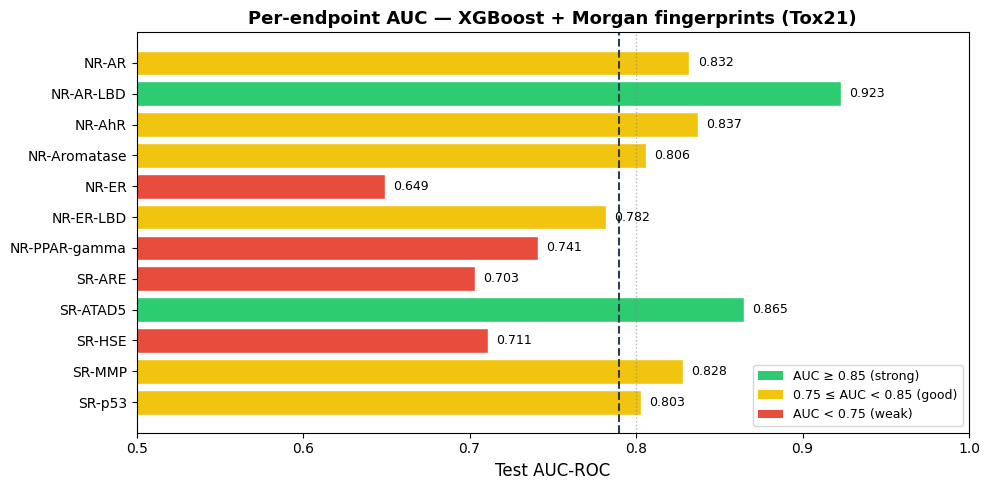

Saved to figures/auc_per_endpoint.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71' if v >= 0.85 else '#f1c40f' if v >= 0.75 else '#e74c3c'
          for v in results_df['Test AUC']]

bars = ax.barh(results_df['Endpoint'], results_df['Test AUC'], color=colors, edgecolor='white')

ax.axvline(x=mean_auc, color='#2c3e50', linestyle='--', linewidth=1.5, label=f'Mean = {mean_auc:.3f}')
ax.axvline(x=0.8, color='gray', linestyle=':', linewidth=1, alpha=0.6, label='AUC = 0.8 reference')

for bar, val in zip(bars, results_df['Test AUC']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlim(0.5, 1.0)
ax.set_xlabel('Test AUC-ROC', fontsize=12)
ax.set_title('Per-endpoint AUC — XGBoost + Morgan fingerprints (Tox21)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='AUC ≥ 0.85 (strong)'),
    Patch(facecolor='#f1c40f', label='0.75 ≤ AUC < 0.85 (good)'),
    Patch(facecolor='#e74c3c', label='AUC < 0.75 (weak)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/auc_per_endpoint.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to figures/auc_per_endpoint.png")

In [9]:
test_smiles = 'Cc1c(C)c2c(c(C)c1O)CCC(C)(COc1ccc(CC3SC(=O)NC3=O)cc1)O2'  # Troglitazone
print(f"Test molecule: Troglitazone ({test_smiles})")
print("(Withdrawn in 2000 for fatal hepatotoxicity)\n")

gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
mol = Chem.MolFromSmiles(test_smiles)
fp = gen.GetFingerprintAsNumPy(mol)
fp_array = np.array(fp).reshape(1, -1)

print("Predictions:")
for task, clf in models.items():
    prob = clf.predict_proba(fp_array)[0, 1]
    flag = "🔴" if prob > 0.7 else "🟡" if prob > 0.4 else "🟢"
    print(f"  {flag} {task}: {prob:.3f}")

Test molecule: Troglitazone (Cc1c(C)c2c(c(C)c1O)CCC(C)(COc1ccc(CC3SC(=O)NC3=O)cc1)O2)
(Withdrawn in 2000 for fatal hepatotoxicity)

Predictions:
  🟢 NR-AR: 0.138
  🟢 NR-AR-LBD: 0.090
  🟢 NR-AhR: 0.086
  🔴 NR-Aromatase: 0.733
  🟢 NR-ER: 0.219
  🟢 NR-ER-LBD: 0.113
  🔴 NR-PPAR-gamma: 0.932
  🟡 SR-ARE: 0.621
  🟢 SR-ATAD5: 0.094
  🔴 SR-HSE: 0.794
  🔴 SR-MMP: 0.881
  🔴 SR-p53: 0.882


In [13]:
known_molecules = {
    'Paracetamol':  ('CC(=O)Nc1ccc(O)cc1',          'Hepatotoxic at high doses'),
    'Aspirin':      ('CC(=O)Oc1ccccc1C(=O)O',        'Generally safe'),
    'Troglitazone': ('Cc1c(C)c2c(c(C)c1O)CCC(C)(COc1ccc(CC3SC(=O)NC3=O)cc1)O2', 'Withdrawn — fatal hepatotoxicity'),
    'Caffeine':     ('Cn1cnc2c1c(=O)n(C)c(=O)n2C',   'Generally safe'),
}

print(f"{'Molecule':<15} {'SR-ARE':>8}  {'Pred':<6}  Reality")
print('-' * 58)
for name, (smi, reality) in known_molecules.items():
    mol = Chem.MolFromSmiles(smi)
    fp = np.array(gen.GetFingerprintAsNumPy(mol)).reshape(1, -1)
    prob = models['SR-ARE'].predict_proba(fp)[0, 1]
    pred = 'HIGH' if prob > 0.5 else 'LOW'
    flag = '✓' if (pred == 'HIGH') == ('safe' not in reality.lower()) else '✗'
    print(f"{name:<15} {prob:>8.3f}  {pred:<6}  {reality} {flag}")

Molecule          SR-ARE  Pred    Reality
----------------------------------------------------------
Paracetamol        0.575  HIGH    Hepatotoxic at high doses ✓
Aspirin            0.419  LOW     Generally safe ✓
Troglitazone       0.621  HIGH    Withdrawn — fatal hepatotoxicity ✓
Caffeine           0.448  LOW     Generally safe ✓


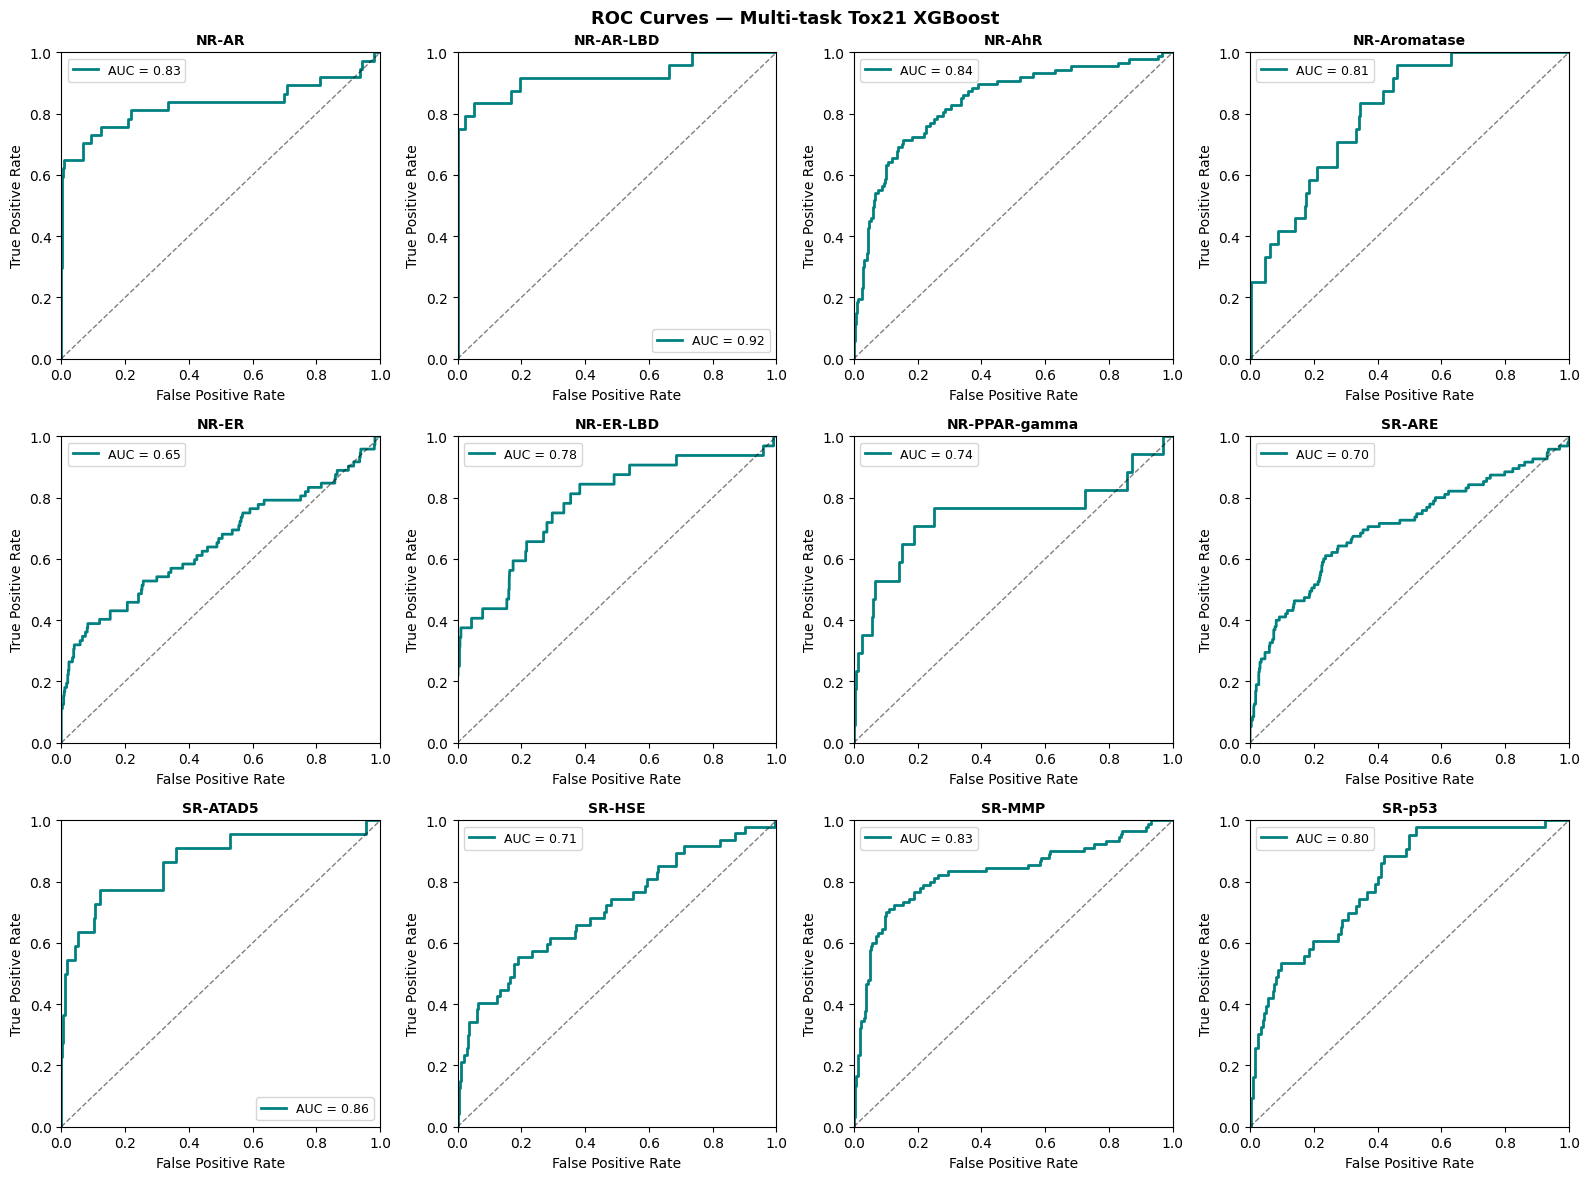

Saved to figures/roc_curves.png


In [14]:
import os
os.makedirs('../figures', exist_ok=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, task in enumerate(tasks):
    valid_mask = w_test[:, i] > 0
    y_true = y_test_clean[valid_mask, i]
    y_score = models[task].predict_proba(X_test[valid_mask])[:, 1]
    
    try:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)
        
        axes[i].plot(fpr, tpr, color='teal', lw=2, label=f'AUC = {auc:.2f}')
        axes[i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
        axes[i].set_title(task, fontsize=10, fontweight='bold')
        axes[i].set_xlabel('False Positive Rate')
        axes[i].set_ylabel('True Positive Rate')
        axes[i].legend(fontsize=9)
        axes[i].set_xlim([0, 1])
        axes[i].set_ylim([0, 1])
    except:
        axes[i].set_title(f"{task}\n(insufficient data)")

plt.suptitle('ROC Curves — Multi-task Tox21 XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to figures/roc_curves.png")

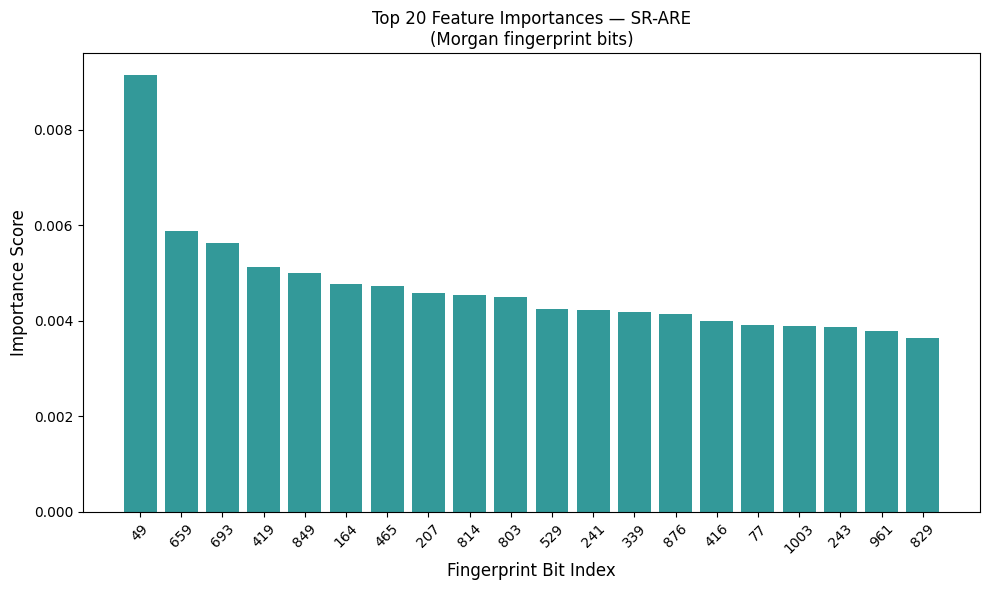

Saved!


In [15]:
# Top 20 features pour SR-ARE 
target_task = 'SR-ARE'
xgb_model = models[target_task]

importances = xgb_model.feature_importances_
top_n = 20
top_indices = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(10, 6))
bars = plt.bar(range(top_n), importances[top_indices], color='teal', alpha=0.8)
plt.xlabel('Fingerprint Bit Index', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.title(f'Top {top_n} Feature Importances — {target_task}\n(Morgan fingerprint bits)', fontsize=12)
plt.xticks(range(top_n), top_indices, rotation=45)
plt.tight_layout()
plt.savefig('../figures/feature_importance_SR_ARE.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

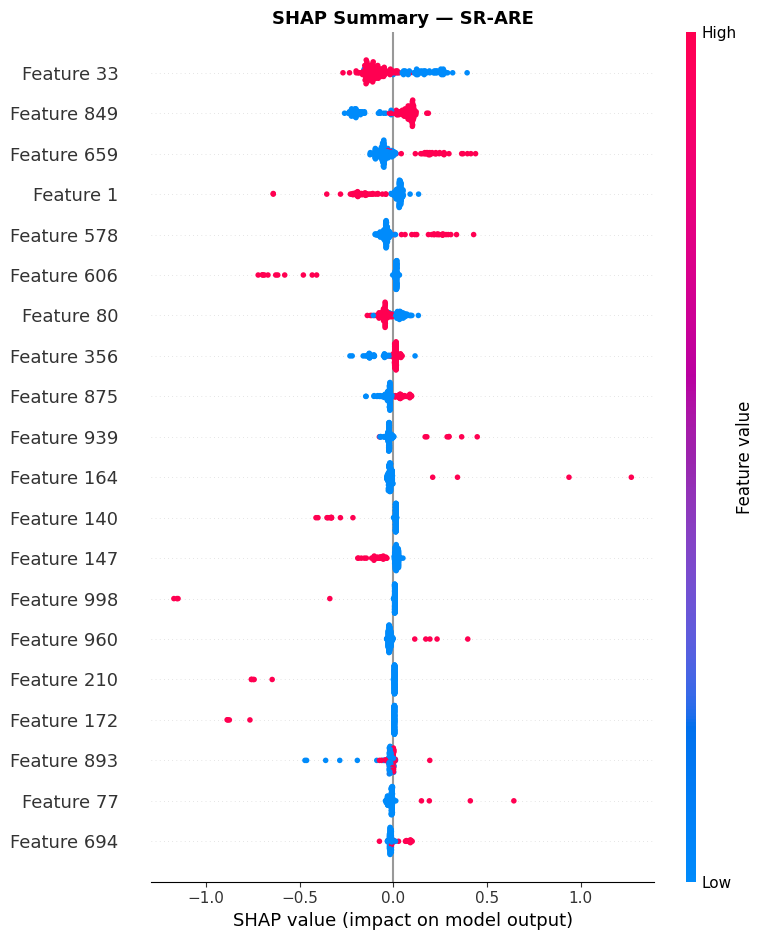

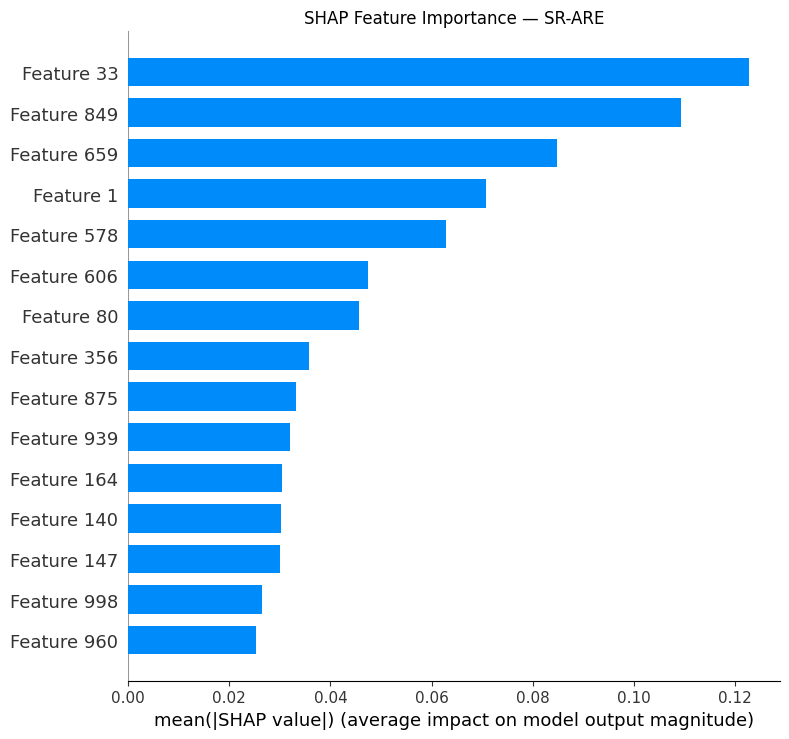

In [16]:
import shap

# SHAP sur SR-ARE
target_task = 'SR-ARE'
xgb_model = models[target_task]

# Explainer
explainer = shap.TreeExplainer(xgb_model)

X_sample = X_test[:200]
shap_values = explainer.shap_values(X_sample)

# Plot 1 — Summary plot
plt.figure()
shap.summary_plot(
    shap_values, 
    X_sample,
    max_display=20,
    show=False
)
plt.title(f'SHAP Summary — {target_task}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/shap_summary_SR_ARE.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — Bar plot 
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title(f'SHAP Feature Importance — {target_task}')
plt.tight_layout()
plt.savefig('../figures/shap_bar_SR_ARE.png', dpi=150, bbox_inches='tight')
plt.show()

## Results Interpretation

### Overall Performance
The multi-task XGBoost achieves a **mean AUC of 0.790** across all 12 Tox21 endpoints, using Morgan fingerprints (ECFP4, radius=2, 1024 bits) with per-endpoint class imbalance correction.

### Strong endpoints (AUC > 0.80)
| Endpoint | AUC | Why |
|----------|-----|-----|
| NR-AR-LBD | 0.923 | Androgen receptor LBD has a rigid, selective binding pocket. Morgan fingerprints capture its structural requirements well |
| NR-ATAD5 | 0.865 | Genotoxicity signal tends to correlate with specific reactive chemical groups (electrophiles) that fingerprints detect |
| NR-AhR | 0.837 | Aryl hydrocarbon receptor preferentially binds planar aromatic structures, well-encoded by circular fingerprints |
| NR-AR | 0.832 | Same reasoning as NR-AR-LBD |
| SR-MMP | 0.828 | Mitochondrial toxicity correlates with lipophilicity and cationic character, captured by fingerprint features |

### Weak endpoint (AUC = 0.649)
**NR-ER (Estrogen receptor)** is the hardest endpoint. Its flexible binding pocket accommodates structurally diverse ligands. 
Morgan fingerprints encode local chemical environments but miss global 3D shape, 
which matters for ER binding. A **Graph Neural Network (GNN)** encoding the full 
molecular graph would likely improve this significantly.

### SR-ARE: our focus endpoint
**AUC = 0.703.** The Nrf2/ARE pathway detects oxidative stress, a key hepatotoxicity signal (Kim et al., 2016, *Environ. Health Perspect.*, 124(5):634-41). 
Performance is acceptable for early-stage screening but suggests that electrophilic 
structural features driving Nrf2 activation are only partially captured by 2D fingerprints.

### Limitations & next steps
- **Fingerprints are 2D** they miss 3D shape, chirality, and conformational flexibility
- **Next step**: replace XGBoost with a Graph Neural Network (e.g. AttentiveFP, MPNN) typically gains 5-10% AUC on harder endpoints like NR-ER